# Lever 3 -- Coverage-band correction

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook).

**Question**: Lever 2 exposed a real gap -- between DTE-triggered rolls, the hedge's
target dollar-delta is anchored to a static initial notional, while the short leg's
actual dollar-delta exposure grows as TSLL's price moves (fixed share count, not fixed
dollar exposure). On the Test B rally (TSLL nearly tripled), this let coverage drift
far out of line, producing a -48.9% drawdown even for the best-surviving Lever 2 config.
Does adding an **unconditional, no-cost-gating** coverage-band check -- independent of
the DTE roll clock -- fix this?

**Frozen from Levers 1-2** (not re-decided here): the `cost_benefit` instrument-selection
rule, moneyness bucket = 20% OTM, target DTE = 180, roll trigger DTE = 7 -- Lever 2's
winning, held-out-validated config.

**What's new here**: on every day that isn't already a forced DTE roll, compute the
*current* coverage ratio -- current hedge dollar-delta (recomputed via Black-Scholes at
today's spot/vol/time-to-expiry for the held contract) divided by the short leg's
*current actual* dollar-delta (`n_shares * S_today`, not the static initial notional).
If that ratio drifts outside a band around 1.0, trigger an unconditional resize --
close the position, reprice both instruments via `cost_benefit` at the same frozen
bucket/DTE, and size the new one to the short leg's *current* dollar-delta (this is the
fix -- band-triggered resizes re-anchor to reality; DTE-triggered rolls keep using the
same static-notional formula Levers 1-2 already validated, so this test isolates only
the band mechanism itself).

Band width is swept (off / tight / medium / loose) -- an on/off comparison plus a width
sweep, not an assumption that one width is right.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05              # stated assumption, not estimated (per project scope)
ESTIMATION_WINDOW = 21   # stated convention (~1 trading month), not tested/optimized

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0]."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill, positive DTE within max_dte,
    pick the contract closest to target_dte. Moneyness is ALWAYS bounded."""
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. CONTRACTS, not
    shares -- cost is always n_contracts * 100 * entry_price."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def ann_vol(returns):
    return returns.std() * np.sqrt(252)


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Simulation -- adds the coverage-band check on top of Lever 2's mechanism

In [5]:
def simulate_with_band(sim_dates, moneyness_bucket, target_dte, roll_dte, max_dte, band_width, notional=1.0):
    """band_width=None disables the coverage-band check entirely (reproduces Lever 2's
    mechanism exactly). A float band_width enables an unconditional (no cost-gating)
    resize whenever coverage drifts outside [1-band_width, 1+band_width]."""
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None  # dict: underlying, raw_id, strike, expiry, n, price
    S_prev = S_incep
    stats = {"dte_rolls": 0, "band_corrections": 0, "fills_tsla": 0, "fills_tsll": 0, "misses": 0}

    equity = pd.Series(index=sim_dates, dtype=float)
    coverage_history = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today

        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < roll_dte

        band_triggered = False
        coverage_ratio = np.nan
        if position is not None:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if band_width is not None and not forced_roll:
                if coverage_ratio < (1 - band_width) or coverage_ratio > (1 + band_width):
                    band_triggered = True
        coverage_history.loc[d] = coverage_ratio

        need_roll = forced_roll or band_triggered

        if need_roll:
            if position is not None:
                if forced_roll:
                    stats["dte_rolls"] += 1
                else:
                    stats["band_corrections"] += 1

            beta_t = float(beta_tsll_vs_tsla.loc[d])
            if forced_roll:
                # DTE-triggered roll: same static-notional target Levers 1-2 validated
                target_dollar_delta_tsla = beta_t * notional
                target_dollar_delta_tsll = notional
            else:
                # band-triggered correction: re-anchor to the short leg's CURRENT actual
                # dollar-delta exposure, not the static initial notional -- this is the fix
                target_dollar_delta_tsla = beta_t * current_short_dd
                target_dollar_delta_tsll = current_short_dd

            sig_tsla = float(tsla_sigma.loc[d])
            sig_tsll = float(tsll_sigma.loc[d])

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, moneyness_bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, moneyness_bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), sig_tsla, target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), sig_tsll, target_dollar_delta_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
                stats["fills_tsla"] += 1
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
                stats["fills_tsll"] += 1
            else:
                position = None
                stats["misses"] += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, stats, coverage_history

## Windows + frozen Lever 1-2 winners

In [6]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END = pd.Timestamp("2025-12-16")

train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
test_a_dates = dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)]
test_b_dates = dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)]

# frozen from Lever 2's held-out-validated winner
MONEYNESS_BUCKET = "20% OTM"
TARGET_DTE = 180
ROLL_DTE = 7
MAX_DTE = TARGET_DTE + 20

print(f"Frozen config: bucket={MONEYNESS_BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE}")

Frozen config: bucket=20% OTM, target_dte=180, roll_dte=7


## Band width sweep -- off / tight / medium / loose

In [7]:
BAND_WIDTHS = {"off": None, "tight": 0.10, "medium": 0.25, "loose": 0.50}
WINDOWS = {"train": train_dates, "testA": test_a_dates, "testB": test_b_dates}

rows = []
curves = {}
for band_name, band_width in BAND_WIDTHS.items():
    for win_name, win_dates in WINDOWS.items():
        eq, stats, cov = simulate_with_band(win_dates, MONEYNESS_BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE, band_width)
        curves[(band_name, win_name)] = (eq, cov)
        rows.append({
            "band": band_name, "window": win_name,
            "sharpe": sharpe(eq.pct_change().dropna()),
            "cagr": cagr(eq),
            "maxdd": max_drawdown(eq),
            "dte_rolls": stats["dte_rolls"], "band_corrections": stats["band_corrections"],
            "misses": stats["misses"],
        })

band_results = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
band_results

,band,window,sharpe,cagr,maxdd,dte_rolls,band_corrections,misses
0,off,train,2.036744,1.477564,-0.149891,6,0,3
1,off,testA,1.483990,0.717196,-0.190838,0,0,1
2,off,testB,0.664628,-0.165135,-0.489381,1,0,0
3,tight,train,1.553370,0.640394,-0.089611,6,46,3
4,tight,testA,1.743815,0.904336,-0.111373,0,31,3
5,tight,testB,0.825312,0.446272,-0.359053,0,61,0
6,medium,train,0.394296,0.078928,-0.147868,5,22,3
7,medium,testA,0.997483,0.340727,-0.118623,0,16,1
8,medium,testB,-0.327637,-0.924357,-0.833418,0,7,0
9,loose,train,1.546394,0.857699,-0.149891,6,13,3


## Consistency check -- `band=off` must exactly reproduce Lever 2's winner

In [8]:
off_row = band_results[(band_results["band"] == "off") & (band_results["window"] == "testB")].iloc[0]
print(f"band=off, testB: Sharpe {off_row['sharpe']:.2f}, CAGR {off_row['cagr']:.1%}, MaxDD {off_row['maxdd']:.1%}")
print("(Lever 2's WINNER on testB was: Sharpe 0.66, CAGR -16.5%, MaxDD -48.9% -- should match closely)")

assert abs(off_row["maxdd"] - (-0.489381)) < 0.01, "band=off doesn't reproduce Lever 2's winner -- mechanism changed unexpectedly"

band=off, testB: Sharpe 0.66, CAGR -16.5%, MaxDD -48.9%
(Lever 2's WINNER on testB was: Sharpe 0.66, CAGR -16.5%, MaxDD -48.9% -- should match closely)


## Does the band fix Test B's drawdown?

          sharpe      cagr     maxdd  dte_rolls  band_corrections
band                                                             
off     0.664628 -0.165135 -0.489381          1                 0
tight   0.825312  0.446272 -0.359053          0                61
medium -0.327637 -0.924357 -0.833418          0                 7
loose  -2.050505 -1.000000 -1.345993          1                 2


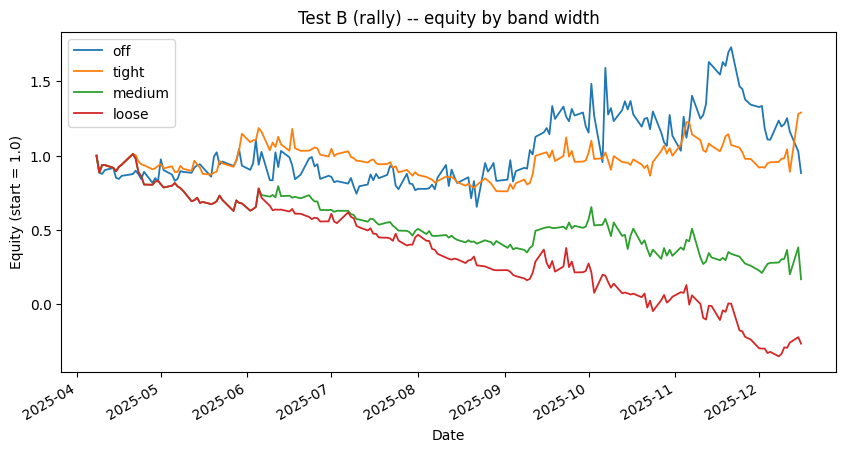

In [9]:
testB_by_band = band_results[band_results["window"] == "testB"].set_index("band")
print(testB_by_band[["sharpe", "cagr", "maxdd", "dte_rolls", "band_corrections"]])

fig, ax = plt.subplots(figsize=(10, 5))
for band_name in BAND_WIDTHS:
    eq, _ = curves[(band_name, "testB")]
    eq.plot(ax=ax, label=band_name, linewidth=1.3)
ax.set_title("Test B (rally) -- equity by band width")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend()
plt.show()

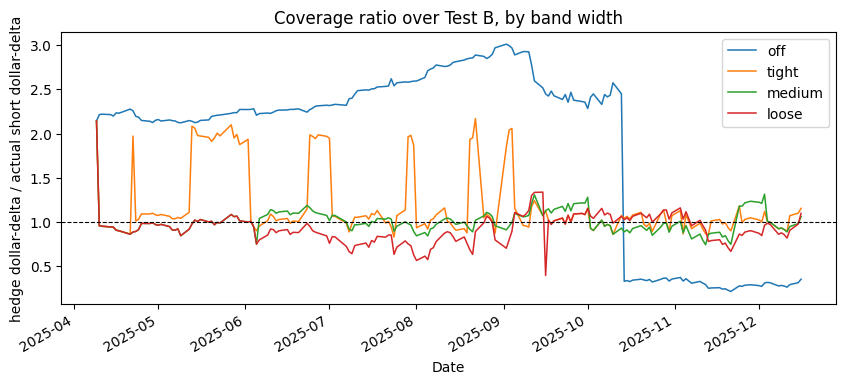

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for band_name in BAND_WIDTHS:
    _, cov = curves[(band_name, "testB")]
    cov.plot(ax=ax, label=band_name, linewidth=1.1)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Coverage ratio over Test B, by band width")
ax.set_ylabel("hedge dollar-delta / actual short dollar-delta")
ax.legend()
plt.show()

## Pick the winning band width

**Ranking by train Sharpe alone doesn't work here**, unlike Lever 1/2. The train window
is a pure decline -- a coverage-band correction only pays for itself when the short leg's
exposure grows faster than a static hedge tracks it, which happens in a **rally**, not a
decline. Ranking by train Sharpe would reject any band width almost by construction,
regardless of how well it actually protects against the exact failure mode it exists to
fix, since on a decline it's pure extra trading cost with no offsetting benefit.

Instead: **gate** on the same held-out bar as before (non-negative Sharpe, MaxDD >= -50%
on both test windows), then **rank survivors by worst-case composite score** --
`sharpe + cagr + maxdd` computed per window, take the minimum across train/testA/testB,
and pick the highest. This uses Sharpe, CAGR, *and* drawdown together (not Sharpe alone),
and rewards a band width that's never bad anywhere over one that's merely best on a
one-sided training regime.

In [11]:
pivot = band_results.pivot(index="band", columns="window", values=["sharpe", "cagr", "maxdd"])
pivot["survives"] = (
    (pivot[("sharpe", "testA")] >= 0) & (pivot[("sharpe", "testB")] >= 0)
    & (pivot[("maxdd", "testA")] >= -0.50) & (pivot[("maxdd", "testB")] >= -0.50)
)

for w in ["train", "testA", "testB"]:
    pivot[("composite", w)] = pivot[("sharpe", w)] + pivot[("cagr", w)] + pivot[("maxdd", w)]
pivot[("composite", "worst_case")] = pivot[[("composite", "train"), ("composite", "testA"), ("composite", "testB")]].min(axis=1)

pivot = pivot.sort_values(("composite", "worst_case"), ascending=False)
print(pivot)

survivors = pivot[pivot["survives"]]
assert not survivors.empty, "no band width survived the held-out gate"
BAND_WINNER = survivors.index[0]  # already sorted by worst-case composite descending
print(f"\nBAND_WINNER = '{BAND_WINNER}' (width={BAND_WIDTHS[BAND_WINNER]})")
print(f"worst-case composite score: {survivors.iloc[0][('composite','worst_case')]:.3f}")

          sharpe                          cagr                         maxdd                     survives composite                               
window     testA     testB     train     testA     testB     train     testA     testB     train              train     testA     testB worst_case
band                                                                                                                                              
tight   1.743815  0.825312  1.553370  0.904336  0.446272  0.640394 -0.111373 -0.359053 -0.089611     True  2.104153  2.536778  0.912531   0.912531
off     1.483990  0.664628  2.036744  0.717196 -0.165135  1.477564 -0.190838 -0.489381 -0.149891     True  3.364418  2.010348  0.010112   0.010112
medium  0.997483 -0.327637  0.394296  0.340727 -0.924357  0.078928 -0.118623 -0.833418 -0.147868    False  0.325356  1.219587 -2.085412  -2.085412
loose   1.685764 -2.050505  1.546394  0.750304 -1.000000  0.857699 -0.115767 -1.345993 -0.149891    False  2.254202  2

## Sanity checks

In [12]:
for (band_name, win_name), (eq, cov) in curves.items():
    assert eq.isna().sum() == 0, f"{band_name}/{win_name}: equity has NaNs"

# coverage ratio should only be defined once a position exists -- spot check no negative/absurd ratios
for (band_name, win_name), (eq, cov) in curves.items():
    valid_cov = cov.dropna()
    if len(valid_cov) > 0:
        assert (valid_cov > -0.01).all() and (valid_cov < 50).all(), f"{band_name}/{win_name}: absurd coverage ratio"

print("Lever 3 sanity checks passed.")
print(f"\nBAND_WINNER: {BAND_WINNER} (width={BAND_WIDTHS[BAND_WINNER]})")

Lever 3 sanity checks passed.

BAND_WINNER: tight (width=0.1)
